<a href="https://colab.research.google.com/github/Shyam5242/NLP-Based-Database-Query-and-Visualization-System/blob/main/NLP_Based_Database_Query_and_Visualization_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving superstore.csv to superstore (4).csv


{'superstore (4).csv': b'Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,State,City,Region,Product Name,Category,Sub-Category,Sales,Quantity,Discount,Profit\r\nCA-1001,2024-01-05,2024-01-07,Second Class,Raja,Consumer,India,Tamil Nadu,Chennai,South,Office Chair,Furniture,Chairs,5000,2,0.10,800\r\nCA-1002,2024-01-06,2024-01-08,Standard Class,John,Corporate,India,Maharashtra,Mumbai,West,Laptop,Technology,Computers,55000,1,0.05,5000\r\nCA-1003,2024-01-07,2024-01-10,First Class,Asha,Home Office,India,Karnataka,Bangalore,South,Printer,Technology,Office Machines,15000,1,0.10,2000\r\nCA-1004,2024-01-08,2024-01-11,Second Class,Ravi,Consumer,India,Delhi,Delhi,North,Table,Furniture,Tables,7000,1,0.15,900\r\nCA-1005,2024-01-09,2024-01-12,Standard Class,Priya,Corporate,India,Telangana,Hyderabad,South,Bookcase,Furniture,Bookcases,9000,2,0.20,1200\r\nCA-1006,2024-01-10,2024-01-13,Second Class,Arun,Consumer,India,Tamil Nadu,Chennai,South,Mouse,Technology,Accessories,1200,3,0.05,3

In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv("superstore.csv")

conn = sqlite3.connect("superstore.db")
df.to_sql("superstore", conn, if_exists="replace", index=False)

df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,State,City,Region,Product Name,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,CA-1001,2024-01-05,2024-01-07,Second Class,Raja,Consumer,India,Tamil Nadu,Chennai,South,Office Chair,Furniture,Chairs,5000,2,0.10,800
1,CA-1002,2024-01-06,2024-01-08,Standard Class,John,Corporate,India,Maharashtra,Mumbai,West,Laptop,Technology,Computers,55000,1,0.05,5000
2,CA-1003,2024-01-07,2024-01-10,First Class,Asha,Home Office,India,Karnataka,Bangalore,South,Printer,Technology,Office Machines,15000,1,0.10,2000
3,CA-1004,2024-01-08,2024-01-11,Second Class,Ravi,Consumer,India,Delhi,Delhi,North,Table,Furniture,Tables,7000,1,0.15,900
4,CA-1005,2024-01-09,2024-01-12,Standard Class,Priya,Corporate,India,Telangana,Hyderabad,South,Bookcase,Furniture,Bookcases,9000,2,0.20,1200


In [ ]:
!pip install nltk

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
SYNONYMS = {
    "sales": ["sales", "revenue", "income"],
    "profit": ["profit", "gain"],
    "region": ["region", "zone"],
    "category": ["category", "type"],
    "top": ["top", "highest", "best"]
}

CITIES = ["Chennai", "Mumbai", "Delhi", "Bangalore", "Hyderabad", "Pune", "Kolkata"]
CATEGORIES = ["Furniture", "Technology", "Office Supplies"]

In [ ]:
def detect_intent(tokens):
    scores = {
        "sales": 0,
        "profit": 0,
        "region": 0,
        "top": 0
    }

    for word in tokens:
        if word in SYNONYMS["sales"]:
            scores["sales"] += 1
        if word in SYNONYMS["profit"]:
            scores["profit"] += 1
        if word in SYNONYMS["region"]:
            scores["region"] += 1
        if word in SYNONYMS["top"]:
            scores["top"] += 1

    # Prioritize 'region' if 'region' is explicitly mentioned and 'sales' is also present
    # This helps resolve ambiguity for queries like "Sales by region"
    if scores["region"] > 0 and scores["sales"] > 0:
        return "region"

    return max(scores, key=scores.get)

In [ ]:
def extract_entities(text):
    city = None
    category = None

    for c in CITIES:
        if c.lower() in text.lower():
            city = c

    for cat in CATEGORIES:
        if cat.lower() in text.lower():
            category = cat

    return city, category


In [ ]:
def generate_sql(query):
    tokens = word_tokenize(query.lower())
    intent = detect_intent(tokens)
    city, category = extract_entities(query)

    sql = "SELECT "

    # SELECT part
    if intent == "sales":
        sql += "SUM(Sales) AS total_sales"
    elif intent == "profit":
        sql += "SUM(Profit) AS total_profit"
    elif intent == "region":
        sql += "Region, SUM(Sales) AS total_sales"
    elif intent == "top":
        sql += '"Product Name", SUM(Sales) AS total_sales'
    else:
        sql += "*"

    # FROM
    sql += " FROM superstore"

    # WHERE
    conditions = []
    if city:
        conditions.append(f'City = "{city}"')
    if category:
        conditions.append(f'Category = "{category}"')

    if conditions:
        sql += " WHERE " + " AND ".join(conditions)

    # GROUP BY / ORDER
    if intent == "region":
        sql += " GROUP BY Region"
    if intent == "top":
        sql += ' GROUP BY "Product Name" ORDER BY total_sales DESC LIMIT 5'

    return sql

In [ ]:
def run_query(sql):
    cursor = conn.cursor()
    cursor.execute(sql)

    cols = [d[0] for d in cursor.description]
    rows = cursor.fetchall()

    return pd.DataFrame(rows, columns=cols)

In [ ]:
def ask_database(query):
    sql = generate_sql(query)
    print("Generated SQL:\n", sql)

    try:
        return run_query(sql)
    except Exception as e:
        return str(e)

In [ ]:
ask_database("Show total sales")
ask_database("Revenue in Chennai")
ask_database("Profit in Mumbai")
ask_database("Sales by region")
ask_database("Top products")
ask_database("Sales in Chennai for Furniture")

Generated SQL:
 SELECT SUM(Sales) AS total_sales FROM superstore
Generated SQL:
 SELECT SUM(Sales) AS total_sales FROM superstore WHERE City = "Chennai"
Generated SQL:
 SELECT SUM(Profit) AS total_profit FROM superstore WHERE City = "Mumbai"
Generated SQL:
 SELECT SUM(Sales) AS total_sales FROM superstore
Generated SQL:
 SELECT "Product Name", SUM(Sales) AS total_sales FROM superstore GROUP BY "Product Name" ORDER BY total_sales DESC LIMIT 5
Generated SQL:
 SELECT SUM(Sales) AS total_sales FROM superstore WHERE City = "Chennai" AND Category = "Furniture"


,total_sales
0,5000


Generated SQL:
 SELECT Region, SUM(Sales) AS total_sales FROM superstore GROUP BY Region


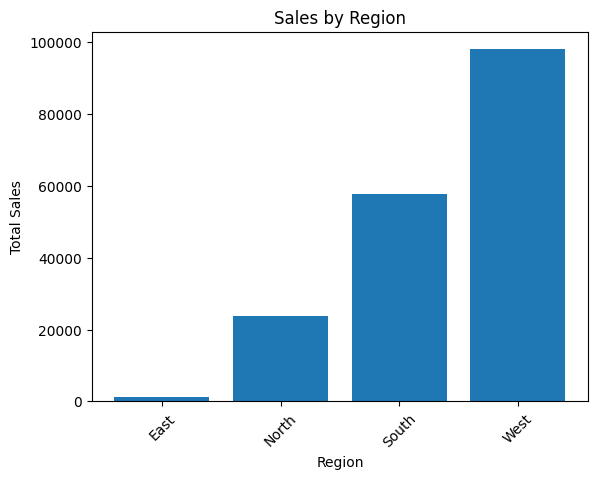

In [ ]:
import matplotlib.pyplot as plt

df = ask_database("Sales by region")

plt.figure()
plt.bar(df[df.columns[0]], df[df.columns[1]])
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()

Generated SQL:
 SELECT "Product Name", SUM(Sales) AS total_sales FROM superstore GROUP BY "Product Name" ORDER BY total_sales DESC LIMIT 5


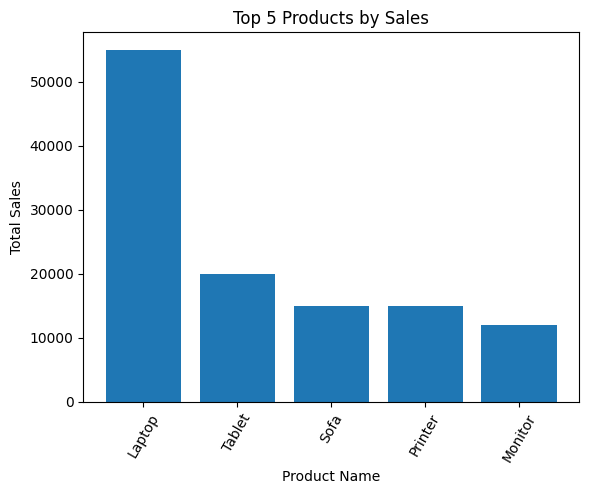

In [ ]:
df = ask_database("Top products")

plt.figure()
plt.bar(df[df.columns[0]], df[df.columns[1]])
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.title("Top 5 Products by Sales")
plt.xticks(rotation=60)
plt.show()

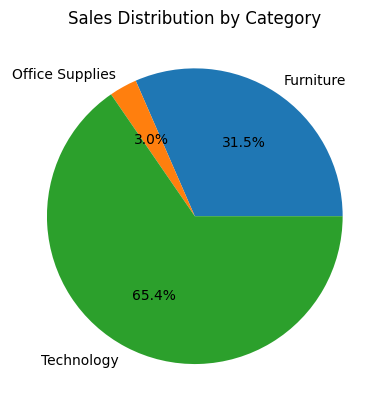

In [ ]:
query = '''
SELECT Category, SUM(Sales) as total_sales
FROM superstore
GROUP BY Category
'''

df = run_query(query)

plt.figure()
plt.pie(df["total_sales"], labels=df["Category"], autopct='%1.1f%%')
plt.title("Sales Distribution by Category")
plt.show()

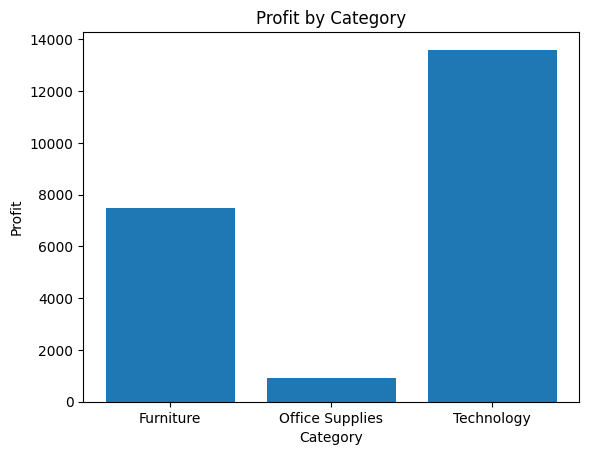

In [ ]:
query = '''
SELECT Category, SUM(Profit) as total_profit
FROM superstore
GROUP BY Category
'''

df = run_query(query)

plt.figure()
plt.bar(df["Category"], df["total_profit"])
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit by Category")
plt.show()

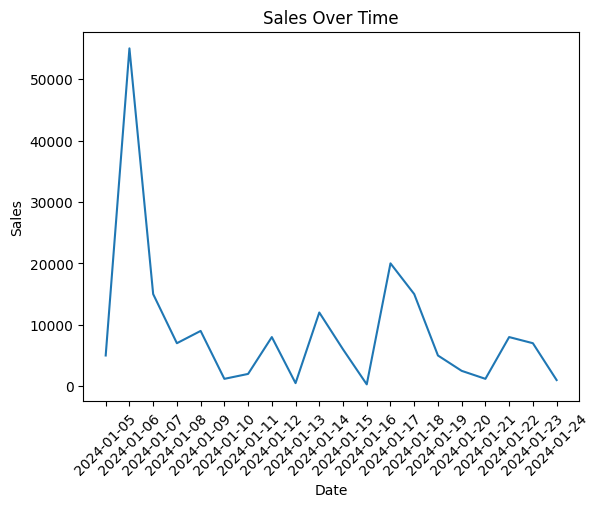

In [ ]:
query = '''
SELECT "Order Date", SUM(Sales) as total_sales
FROM superstore
GROUP BY "Order Date"
ORDER BY "Order Date"
'''

df = run_query(query)

plt.figure()
plt.plot(df["Order Date"], df["total_sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Over Time")
plt.xticks(rotation=45)
plt.show()

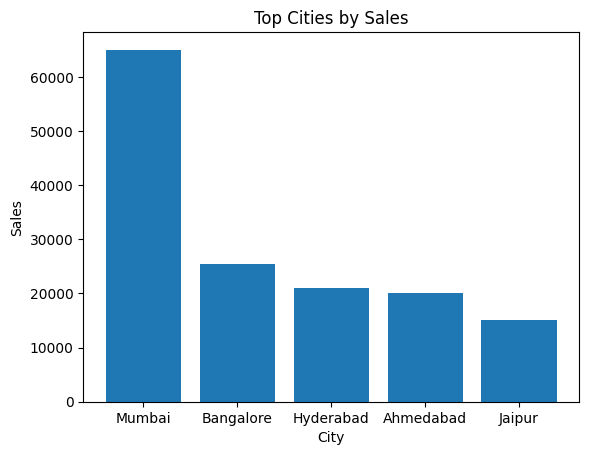

In [ ]:
query = '''
SELECT City, SUM(Sales) as total_sales
FROM superstore
GROUP BY City
ORDER BY total_sales DESC
LIMIT 5
'''

df = run_query(query)

plt.figure()
plt.bar(df["City"], df["total_sales"])
plt.xlabel("City")
plt.ylabel("Sales")
plt.title("Top Cities by Sales")
plt.show()